# Real World Classification

## Load data

Import the necessary libraries

In [19]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
seed=40
np.random.seed(seed)

load the data

In [21]:
import pandas as pd

# load data
df = pd.read_csv('data/NYCU_Iris.csv')

# vyber numerické sloupce
numeric_df = df.select_dtypes(include=['number'])

# výpočty
median_values = numeric_df.median()
std_values = numeric_df.std()

# filtr: jen nenulové hodnoty
median_nonzero = median_values[median_values != 0]
std_nonzero = std_values[std_values != 0]

# výpis median
print("Median:")
for col, val in median_nonzero.items():
    print(f"{col}: {val}")

# výpis std
print("\nStandard deviation:")
for col, val in std_nonzero.items():
    print(f"{col}: {val}")

Median:
Id: 250.5
SepalLengthCm: 6.3
SepalWidthCm: 2.9
PetalLengthCm: 5.085611510791367
PetalWidthCm: 1.6
BranchLength: 16.3
AvgDust: 44.0
SepalLengthMajorAxis: 6.316421934120221
SepalLengthMinorAxis: 6.31031544209928
SepalLengthElongation: 6.320980451891499
SepalLengthCompactness: 6.332139265692754
SepalLengthSpread: 6.319995961681744
SepalLengthCurvature: 6.324463539348475
SepalWidthMajorAxis: 2.83127124781612
SepalWidthMinorAxis: 2.8411318987323253
SepalWidthElongation: 2.835939574033791
SepalWidthCompactness: 2.8431686241868595
SepalWidthSpread: 2.8393511261528768
SepalWidthCurvature: 2.8340628464577584
PetalLengthMajorAxis: 5.023524507051234
PetalLengthMinorAxis: 5.034102104875855
PetalLengthElongation: 5.028692632832937
PetalLengthCompactness: 5.025172446308207
PetalLengthSpread: 5.022804169495634
PetalLengthCurvature: 5.0356848747775125
PetalWidthMajorAxis: 1.673776658517833
PetalWidthMinorAxis: 1.6777021433614974
PetalWidthElongation: 1.6760034520745213
PetalWidthCompactness: 1

## Data Preprocessing

In [22]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # find columns with missing values
    cols_with_missing = df[feature_cols].columns[df[feature_cols].isnull().any()]

    print("Columns with missing values:")
    print(list(cols_with_missing))

    # ---------- BEFORE ----------
    print("\nBEFORE imputation:")

    print("\nMedian:")
    for col in cols_with_missing:
        print(f"{col}: {df[col].median()}")

    print("\nStandard deviation:")
    for col in cols_with_missing:
        print(f"{col}: {df[col].std()}")

    # ---------- KNN IMPUTATION ----------
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    # -----------------------------------

    # ---------- AFTER ----------
    print("\nAFTER imputation:")

    print("\nMedian:")
    for col in cols_with_missing:
        print(f"{col}: {df[col].median()}")

    print("\nStandard deviation:")
    for col in cols_with_missing:
        print(f"{col}: {df[col].std()}")

    return df, feature_cols


# load dataset
df = pd.read_csv('data/NYCU_Iris.csv')

# run preprocessing
df, feature_cols = data_preprocessing(df)

Columns with missing values:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'BranchLength']

BEFORE imputation:

Median:
SepalLengthCm: 6.3
SepalWidthCm: 2.9
PetalLengthCm: 5.085611510791367
PetalWidthCm: 1.6
BranchLength: 16.3

Standard deviation:
SepalLengthCm: 1.0371145018646923
SepalWidthCm: 0.38956399923008017
PetalLengthCm: 1.5828073840563788
PetalWidthCm: 0.706689351902183
BranchLength: 1.0352277983261677

AFTER imputation:

Median:
SepalLengthCm: 6.3
SepalWidthCm: 2.9
PetalLengthCm: 5.03568345323741
PetalWidthCm: 1.7
BranchLength: 16.3

Standard deviation:
SepalLengthCm: 1.009274811778924
SepalWidthCm: 0.37243395723941447
PetalLengthCm: 1.514954874934102
PetalWidthCm: 0.6946450531744969
BranchLength: 1.0110123928602626


In [23]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

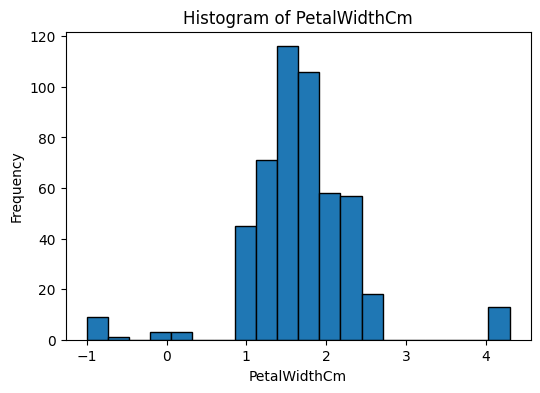

Feature with highest positive correlation:
PetalWidthCompactness: 0.9916701901370253

Top 5 features with strongest negative correlations:
SepalWidthMajorAxis: -0.09635042983649401
SepalGlossIndex: -0.09520000072196652
SepalWidthCompactness: -0.0884963955916379
SepalWidthCurvature: -0.0813343822833098
SepalWidthMinorAxis: -0.07439241023821906


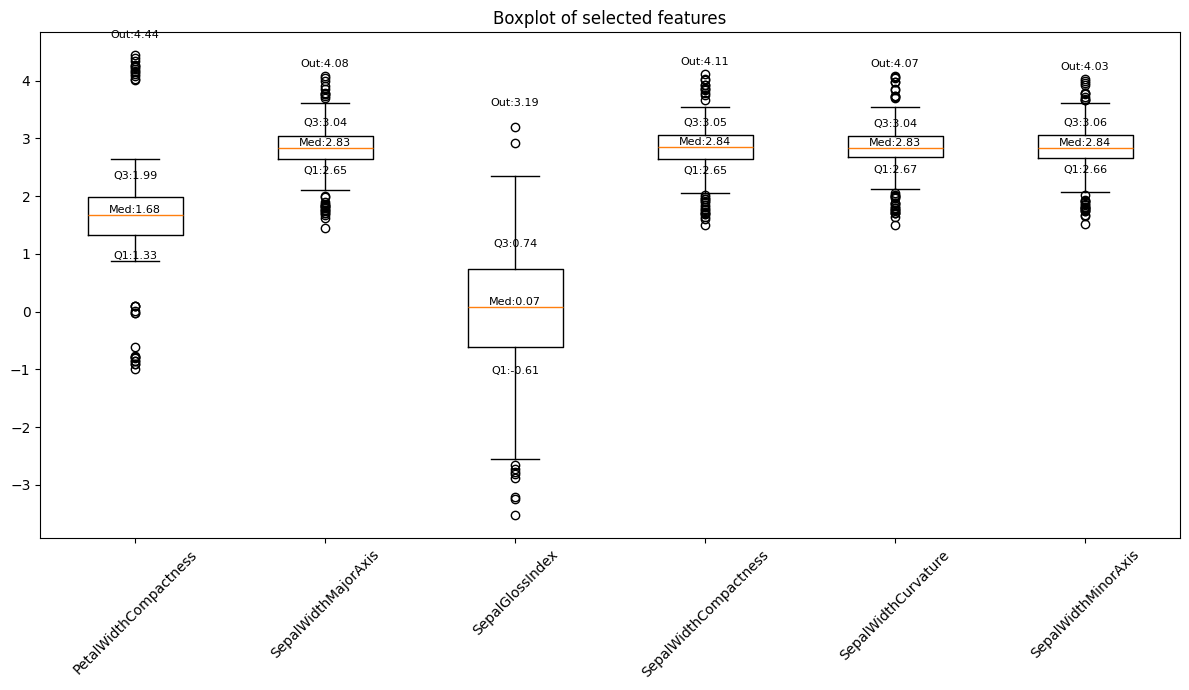

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.feature_selection import r_regression

# ---------- 4(a) Histogram ----------
data = df['PetalWidthCm'].dropna()

plt.figure(figsize=(6,4))

# histogram pouze s okraji
plt.hist(data, bins=20, edgecolor='black')

plt.title('Histogram of PetalWidthCm')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.show()

# ---------- 4(b) Pearson correlation ----------
exclude_cols = ['PetalWidthCm', 'Species', 'Id']
features = [col for col in df.columns if col not in exclude_cols]

X = df[features]
y = df['PetalWidthCm']

corr_values = r_regression(X, y)

corr_df = pd.DataFrame({
    'Feature': features,
    'Correlation': corr_values
})

top_positive = corr_df.sort_values(by='Correlation', ascending=False).iloc[0]

print("Feature with highest positive correlation:")
print(f"{top_positive['Feature']}: {top_positive['Correlation']}")

# ---------- 4(c) Top 5 negative correlations ----------
top_negative = corr_df.sort_values(by='Correlation').head(5)

print("\nTop 5 features with strongest negative correlations:")
for _, row in top_negative.iterrows():
    print(f"{row['Feature']}: {row['Correlation']}")

# ---------- 4(d) Boxplot ----------
selected_features = [top_positive['Feature']] + list(top_negative['Feature'])

plt.figure(figsize=(12,7))  # větší prostor
box_data = [df[col].dropna() for col in selected_features]

plt.boxplot(box_data, labels=selected_features)

# přidání hodnot s offsetem (aby se nepřekrývaly)
for i, col in enumerate(selected_features):
    d = df[col].dropna()
    med = np.median(d)
    q1 = np.percentile(d, 25)
    q3 = np.percentile(d, 75)

    iqr = q3 - q1
    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr
    outs = d[(d < lb) | (d > ub)]
    max_out = outs.max() if len(outs) > 0 else None

    x = i + 1

    # větší vertikální odsazení
    plt.text(x, med, f'Med:{med:.2f}', ha='center', va='bottom', fontsize=8)
    plt.text(x, q1 - 0.05*(max(d)-min(d)), f'Q1:{q1:.2f}', ha='center', va='top', fontsize=8)
    plt.text(x, q3 + 0.05*(max(d)-min(d)), f'Q3:{q3:.2f}', ha='center', va='bottom', fontsize=8)

    if max_out is not None:
        plt.text(x, max_out + 0.05*(max(d)-min(d)), f'Out:{max_out:.2f}', ha='center', va='bottom', fontsize=8)

plt.title("Boxplot of selected features")
plt.xticks(rotation=45)
plt.tight_layout()  # lepší spacing
plt.show()

## Model Training

### Prepare the data

In [25]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split


# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

50. Training loss: 0.6572950512169217, Val loss:0.6699856821878871
100. Training loss: 0.6226307711490021, Val loss:0.6436636316717124
150. Training loss: 0.5968536106438317, Val loss:0.6248019734101419
200. Training loss: 0.5770724410855091, Val loss:0.6109725987973054
250. Training loss: 0.5614500987624708, Val loss:0.6006341363275265
300. Training loss: 0.5488013196405573, Val loss:0.5927862551965061
350. Training loss: 0.5383413721955611, Val loss:0.5867610521735693
400. Training loss: 0.5295356518896497, Val loss:0.5820996162672264
450. Training loss: 0.5220096572557988, Val loss:0.5784781297261022
500. Training loss: 0.51549415543084, Val loss:0.5756625817533594
550. Training loss: 0.5097909798441069, Val loss:0.573480262206977
600. Training loss: 0.5047511496548615, Val loss:0.5718013280805994
650. Training loss: 0.5002605183372977, Val loss:0.5705265741611238
700. Training loss: 0.49623013467643184, Val loss:0.5695791245134201
750. Training loss: 0.49258962365573294, Val loss:0

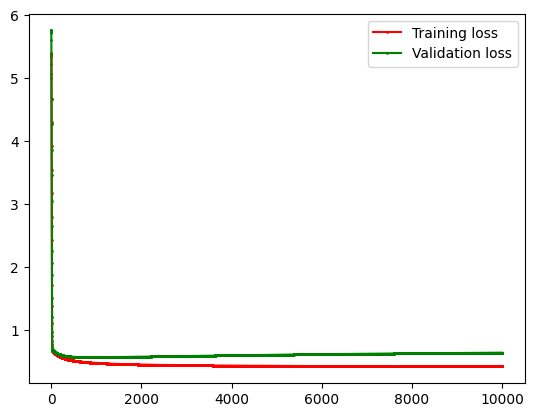

Model parameters (weights): [[-3.16335176]
 [ 1.08853101]
 [ 0.71350466]
 [-0.8911023 ]
 [ 1.66226609]
 [ 0.5786216 ]
 [ 0.3065608 ]
 [-0.22656249]
 [ 0.60023229]
 [ 1.34775177]
 [ 1.12105697]
 [ 0.13582979]
 [ 0.91532985]
 [-0.25514498]
 [-1.06000782]
 [ 0.02580588]
 [ 1.29641721]
 [ 0.46583142]
 [ 0.708017  ]
 [-0.36421518]
 [ 1.03551315]
 [ 0.91255039]
 [-0.28515676]
 [ 0.96740435]
 [-0.2501886 ]
 [ 1.86846412]
 [ 1.65606493]
 [ 1.427259  ]
 [ 1.94460281]
 [ 2.01542746]
 [ 1.41402383]
 [-2.26918045]
 [ 1.53705993]
 [-0.36344481]
 [ 0.19244885]
 [-1.44748147]
 [ 0.70819491]
 [-1.04435298]
 [-2.97198857]
 [-0.42692794]
 [-1.24261354]
 [-0.41796296]
 [-0.98414705]
 [-1.22924233]
 [ 0.50058516]
 [-0.04456719]
 [ 0.02405468]
 [ 0.32226938]
 [-0.64850895]
 [-0.66593166]
 [-0.48056443]
 [ 0.32707679]
 [ 0.17495455]
 [-0.61593367]
 [-0.36535728]
 [ 0.49267489]
 [-0.85987899]
 [-1.26373002]
 [-0.28735217]
 [ 0.57001036]
 [-1.02409882]
 [ 0.71907016]
 [ 0.6272286 ]
 [-1.5667075 ]
 [ 0.1079384

In [26]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='', reg_lambda=0)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


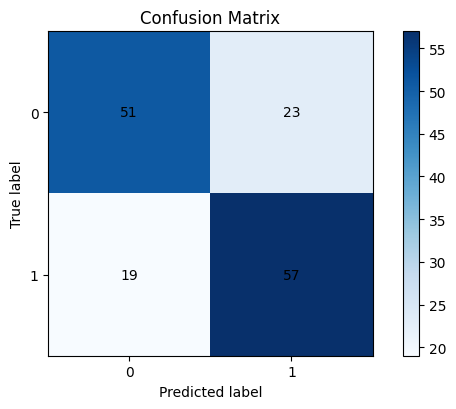

{'Accuracy': 0.72,
 'Precision': 0.7125,
 'Recall': 0.75,
 'F1-score': 0.7307692307692307}

In [27]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)

In [28]:
## Assignment 2 

## Assignment 2 

### K-fold Cross-Validation

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from model.linear_model import LinearModel
from model.activations import sigmoid
from model.gradients import logloss_sigmoid_grad

# 1. Definice ztrátové funkce (aby model neházel TypeError)
def simple_log_loss(y_true, y_pred):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps) # prevence log(0)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 2. Příprava dat z tvého preprocessingu
# Ujisti se, že proměnné 'df' a 'feature_cols' existují (spusť buňku s preprocessingem)
X = df[feature_cols].values 
y = df['Species'].values

# 3. Nastavení hyperparametrů a K-Fold
learning_rates = [0.005, 0.01, 0.1, 0.5]
reg_lambdas = [1.0, 2.0, 4.0, 8.0]
kf = KFold(n_splits=5, shuffle=True, random_state=40)

results = []

print("Spouštím výpočet pro 16 kombinací... (může to chvíli trvat)")

# 4. Výpočet průměrné přesnosti pro každou kombinaci
for lr in learning_rates:
    row = []
    for lam in reg_lambdas:
        # Inicializace modelu se všemi potřebnými funkcemi
        model = LinearModel(
            lr=lr, 
            reg_lambda=lam, 
            reg_type='l2', 
            is_reg=False,
            act_fn=sigmoid,
            grad_fn=logloss_sigmoid_grad,
            loss_fn=simple_log_loss, 
            n_iteration=100, 
            plot_curve=False,
            verbose=False
        )
        
        # Výpočet 5-fold Cross-Validation pomocí scikit-learn
        # cross_val_score interně volá model.fit() a model.score()
        scores = cross_val_score(model, X, y, cv=kf)
        row.append(np.mean(scores))
        
    results.append(row)
    print(f"Hotovo pro Learning Rate: {lr}")

# 5. Vygenerování a zobrazení finální tabulky
df_final_table = pd.DataFrame(
    results, 
    index=[f'LR {lr}' for lr in learning_rates], 
    columns=[f'L2 {l}' for l in reg_lambdas]
)

print("\n--- Table of Average Accurancy (5-FOLD CV) ---")
display(df_final_table)

Spouštím výpočet pro 16 kombinací... (může to chvíli trvat)
Hotovo pro Learning Rate: 0.005
Hotovo pro Learning Rate: 0.01
Hotovo pro Learning Rate: 0.1
Hotovo pro Learning Rate: 0.5

--- Table of Average Accurancy (5-FOLD CV) ---


,L2 1.0,L2 2.0,L2 4.0,L2 8.0
LR 0.005,0.520,0.520,0.520,0.520
LR 0.01,0.520,0.520,0.520,0.520
LR 0.1,0.668,0.664,0.670,0.686
LR 0.5,0.728,0.632,0.528,0.446



=== Evaluating Top 1 Setting (LR=0.5, Lambda=1.0) ===
Model Evaluation
Accuracy  : 0.7467
Precision : 0.7375
Recall    : 0.7763
F1-score  : 0.7564


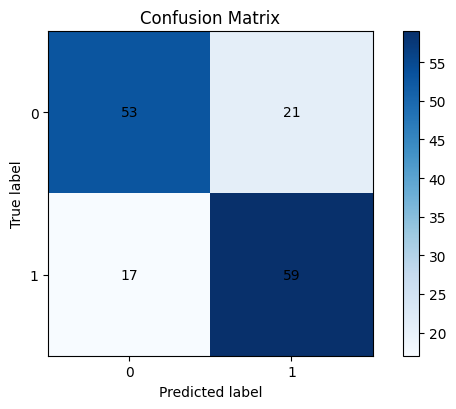


=== Evaluating Top 2 Setting (LR=0.1, Lambda=8.0) ===
Model Evaluation
Accuracy  : 0.7067
Precision : 0.6600
Recall    : 0.8684
F1-score  : 0.7500


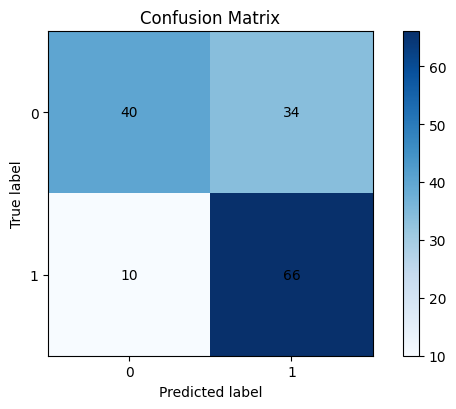

In [30]:

def run_final_evaluation(lr, lam, setting_name):
    print(f"\n=== Evaluating {setting_name} (LR={lr}, Lambda={lam}) ===")
    
    # 1. Inicializace modelu s vítěznými parametry
    model = LinearModel(
        lr=lr, 
        reg_lambda=lam, 
        reg_type='l2', 
        is_reg=False,
        act_fn=sigmoid,
        grad_fn=logloss_sigmoid_grad,
        loss_fn=simple_log_loss,
        n_iteration=500, # Můžeš nechat 500 pro lepší konvergenci
        plot_curve=False,
        verbose=False
    )
    
    # 2. Trénink na CELÝCH trénovacích datech (bez CV)
    model.fit(X_train, y_train)
    
    # 3. Predikce na testovacích datech
    y_pred = model.predict(X_test)
    
    # 4. Evaluace pomocí požadované funkce
    # (Ujisti se, že evaluate_binary_classifier máš definovanou v notebooku)
    evaluate_binary_classifier(y_test, y_pred)

# --- SPUŠTĚNÍ PRO TOP 2 NASTAVENÍ ---

# Nastavení 1 (nejlepší)
run_final_evaluation(lr=0.5, lam=1.0, setting_name="Top 1 Setting")

# Nastavení 2 (druhé nejlepší)
run_final_evaluation(lr=0.1, lam=8.0, setting_name="Top 2 Setting")

### SVM

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# 1. Načtení dat
df = pd.read_csv('data/mobile_price.csv')
X = df.drop('price_range', axis=1)
y = df['price_range']

# 2. Rozdělení dat v poměru 60% / 20% / 20%
# Nejdříve oddělíme 60 % pro trénování a 40 % pro zbytek (validation + testing)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, shuffle=True
)

# Zbylých 40 % rozdělíme na polovinu, abychom získali 20 % a 20 %
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True
)

# 3. Trénování SVM classifieru (C=1.0)
svm_model = SVC(C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

# 4. Výpočet a report výsledků
def evaluate(model, X_set, y_set, name):
    y_pred = model.predict(X_set)
    acc = accuracy_score(y_set, y_pred)
    f1 = f1_score(y_set, y_pred, average='weighted')
    print(f"{name} Results:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-score: {f1:.4f}\n")

evaluate(svm_model, X_train, y_train, "Training")
evaluate(svm_model, X_val, y_val, "Validation")
evaluate(svm_model, X_test, y_test, "Testing")

Training Results:
  Accuracy: 0.9450
  F1-score: 0.9445

Validation Results:
  Accuracy: 0.9450
  F1-score: 0.9448

Testing Results:
  Accuracy: 0.9575
  F1-score: 0.9573



Trénování modelů pro různé hodnoty C...
C=0.001 hotovo.
C=0.01 hotovo.
C=0.1 hotovo.
C=1 hotovo.
C=10 hotovo.
C=100 hotovo.
C=1000 hotovo.
C=10000 hotovo.


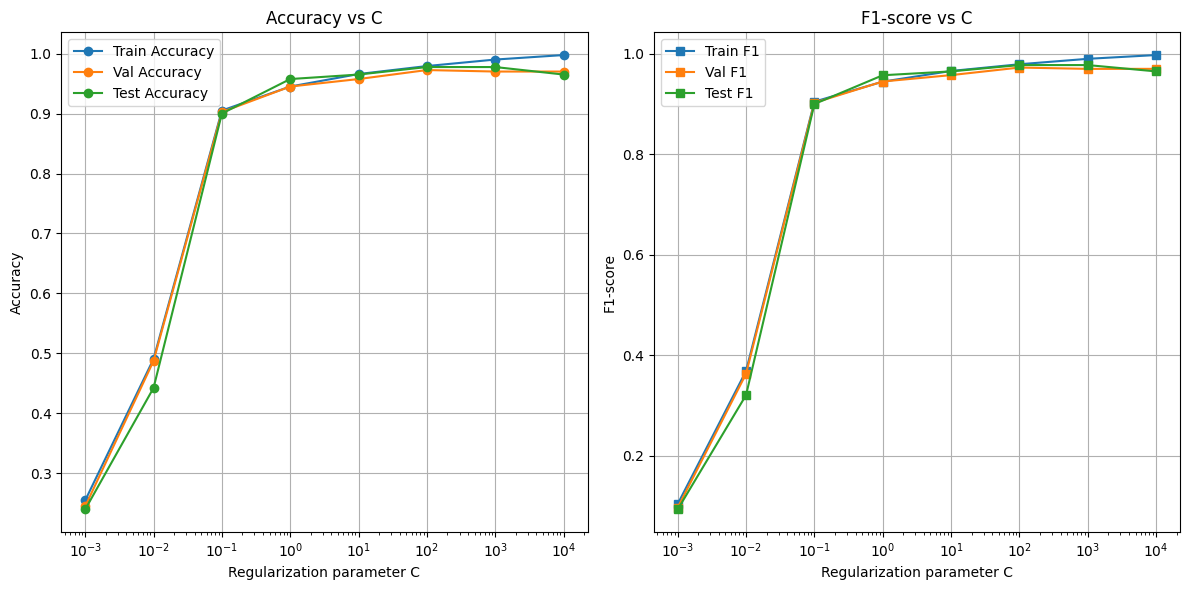

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# 1. Definice hodnot C (0.001 až 10000)
c_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

# Seznamy pro ukládání výsledků
train_accs, val_accs, test_accs = [], [], []
train_f1s, val_f1s, test_f1s = [], [], []

print("Trénování modelů pro různé hodnoty C...")

for c in c_values:
    # Inicializace a trénink SVM
    svm = SVC(C=c, random_state=42)
    svm.fit(X_train, y_train)
    
    # Výpočet Accuracy
    train_accs.append(accuracy_score(y_train, svm.predict(X_train)))
    val_accs.append(accuracy_score(y_val, svm.predict(X_val)))
    test_accs.append(accuracy_score(y_test, svm.predict(X_test)))
    
    # Výpočet F1-score (weighted)
    train_f1s.append(f1_score(y_train, svm.predict(X_train), average='weighted'))
    val_f1s.append(f1_score(y_val, svm.predict(X_val), average='weighted'))
    test_f1s.append(f1_score(y_test, svm.predict(X_test), average='weighted'))
    
    print(f"C={c} hotovo.")

# 2. Vizualizace výsledků
plt.figure(figsize=(12, 6))

# Graf pro Accuracy
plt.subplot(1, 2, 1)
plt.plot(c_values, train_accs, label='Train Accuracy', marker='o')
plt.plot(c_values, val_accs, label='Val Accuracy', marker='o')
plt.plot(c_values, test_accs, label='Test Accuracy', marker='o')
plt.xscale('log') # Logaritmická osa X, protože C roste skokově
plt.xlabel('Regularization parameter C')
plt.ylabel('Accuracy')
plt.title('Accuracy vs C')
plt.legend()
plt.grid(True)

# Graf pro F1-score test
plt.subplot(1, 2, 2)
plt.plot(c_values, train_f1s, label='Train F1', marker='s')
plt.plot(c_values, val_f1s, label='Val F1', marker='s')
plt.plot(c_values, test_f1s, label='Test F1', marker='s')
plt.xscale('log')
plt.xlabel('Regularization parameter C')
plt.ylabel('F1-score')
plt.title('F1-score vs C')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Association Rule Mining

In [2]:
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth

# 1. Načtení a filtrace dat pro price_range = 1
df_mobile = pd.read_csv('data/mobile_price.csv')
df_q3 = df_mobile[df_mobile['price_range'] == 1].copy()

# 2. Definice sloupců pro analýzu
features = ['ram', 'int_memory', 'px_width', 'battery_power']
df_selected = df_q3[features].copy()

def categorize_343(series):
    f_min = series.min()
    f_max = series.max()
    f_range = f_max - f_min
    
    # Definice hranic podle poměru 3:4:3
    low_bound = f_min + 0.3 * f_range
    high_bound = f_min + 0.7 * f_range # (0.3 low + 0.4 medium)
    
    def get_label(val):
        if val <= low_bound: return f"{series.name}_low"
        elif val <= high_bound: return f"{series.name}_medium"
        else: return f"{series.name}_high"
    
    return series.apply(get_label)

# Aplikace kategorizace
transactions_df = pd.DataFrame()
for col in features:
    transactions_df[col] = categorize_343(df_selected[col])

# 3. Převod na One-Hot Encoding pro FP-growth
# FP-growth vyžaduje matici True/False (nebo 0/1)
encoded_df = pd.get_dummies(transactions_df)

# 4. FP-growth s minimálním supportem 0.3
frequent_itemsets = fpgrowth(encoded_df, min_support=0.3, use_colnames=True)

# Seřazení výsledků podle supportu pro přehlednost
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

print("--- Časté vzory (Support >= 0.3) ---")
display(frequent_itemsets)

--- Časté vzory (Support >= 0.3) ---


,support,itemsets
2,0.682,frozenset({ram_ram_medium})
3,0.416,frozenset({px_width_px_width_medium})
5,0.414,frozenset({battery_power_battery_power_medium})
4,0.412,frozenset({int_memory_int_memory_medium})
7,0.318,"frozenset({ram_ram_medium, battery_power_batte..."
0,0.316,frozenset({int_memory_int_memory_low})
1,0.308,frozenset({battery_power_battery_power_low})
6,0.306,"frozenset({px_width_px_width_medium, ram_ram_m..."
